In [250]:
import os
import re
import nltk
from nltk import Tree

import spacy
# spacy.cli.download("nl_core_news_lg")
nlp = spacy.load("nl_core_news_lg") 

import pandas as pd
import numpy as np

import textdescriptives as td

from dataset_evaluation.utils import add_column
from dataset_evaluation.evaluation_framework import EvaluationFramework

import folia.main as folia
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
from datasets import load_dataset

import pylangacq
import ast
from matplotlib.lines import Line2D
from matplotlib import cm, colors as mcolors

from diversity import (
    compression_ratio,
    homogenization_score
)


plt.style.use("seaborn-v0_8-whitegrid")

# Datasets

In [50]:
# generated corpus
first_prompting = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/prompt_results.csv')

## Generated corpus (tinystories translated)

In [2]:
# generated corpus
tinystories_dutch = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/TinyStories/tinystories_part_dutch.csv')

## Narrative dataset (ChiSCor)

In [3]:
path_name = '/Users/sabijn/Documents/PhD/Datasets/chisor_dataset_all/ChiSCor_CoNLL_paper/csv/ChiSCor_master_df_password/ChiSCor_master_df.csv'
df_chiscor = pd.read_csv(path_name, index_col=0)

## Reference corpus (standard)

In [4]:
ref_standard_dep = Path('datasets/BasiScript/BS_dep_lexicon.csv')
ref_standard_uni = Path('datasets/BasiScript/BS_unigram_lexicon.csv')
ref_standard_bi = Path('datasets/BasiScript/BS_bigram_lexicon.csv')

## Reference corpus (spoken)

In [5]:
ref_spoken_b_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_bigram.csv')
ref_spoken_u_csv  = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_unigram.csv')
ref_spoken_t_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/CGN/CGN_pos_trigram.csv')

# Evaluations

Linguistic annotations
- Syntactic tree depth per sentence according to the WNU_2022 paper (van Duijn & van Dijk, 2022)
    - Number of dependency arcs between root and leaf node.
- Average no. of complements per utterance
     - Counts (Open) clausal complements
- Sentence complexity (words before the root)
- Lexical diversity
    - Standard TTR (not implemented).  
    Dividing the number of unique tokens (types) by the total number of tokens.  
    Problem with TTR is that it is lower with a large amount of tokens
    - msTTR (mean segmental type-token ratio (TTR)): 
    
    - maTTR (moving average TTR)
    - MTLD (average number of words for which a consecutive TTR is maintained).  
    Measure of Textual Lexical Diversity.
    - MTLD (moving)
    - MTLD (bidirectional)
    - HDD (bidirectional)
- Vendi score
- Dependency constrained perplexity
- Regular perplexity
- Past tense use
- MAUVE (diversity)

In [7]:
eval_f = EvaluationFramework(language='nl',
                              pos_unigram=ref_spoken_u_csv, 
                              pos_bigram=ref_spoken_b_csv,
                              pos_trigram=ref_spoken_t_csv,
                              ref_unigram=ref_standard_uni,
                              ref_bigram=ref_standard_bi,
                              ref_ling_constrained=ref_standard_dep,
                              embedding_model='jegormeister/bert-base-dutch-cased')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/437M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Syntatic tree depth
-- van Duijn & van Dijk (2022)

In [9]:
eval_f.add_pipe('syntactic_depth')

## Average no. of complements per utterance

In [10]:
eval_f.add_pipe('average_components')

## Sentence complexity
-- ChiSCor (2023) - Average number of words before the root

In [11]:
eval_f.add_pipe('wbr_average')

## Lexical diversity
-- ChiSCor (2023)

In [12]:
eval_f.add_pipe('lexical_diversity')

## Dependency distance
-- ChiSCor (2023)

In [ ]:
eval_f.add_pipe('dependency_distance')

## Local contextuality

In [14]:
eval_f.add_pipe("local_contextuality")

## Grammaticality

$G(story) = \dfrac{\sum^k_{i=1}(G(s_i))}{k}$, with $s$ a sentence in the story.  
  
$G(sentence) = P(seq) = \log(\sqrt[n]{\prod_{i=1}^n \left( P(K_i) \right)})$.  
  
$P(K_i) = P(t_3t_2t_1) = \lambda_1 \cdot P(t_3|t_1t_2) + \lambda_2 \cdot P(t_3|t_2) + \lambda_3 \cdot P(t_3)$, where  
  
- where $\lambda_1 + \lambda_2 + \lambda_3 = 1$, ($\lambda_1 = 0.5, \lambda_2 = 0.3, \lambda_3 = 0.2 \rightarrow$ vadlapudi (2010))
- $P(t_3|t_1t_2) = \dfrac{f(t_1t_2t_3)}{f(t_1t_2)}$.  
- $P(t_3|t_2) = \dfrac{f(t_2t_3)}{f(t_2)}$.  
- $P(t_3) = \dfrac{f(t_3)}{\sum_{\forall t_i} f(t_i)}$


In [15]:
eval_f.add_pipe('grammaticality')

## Creative perplexity

In [ ]:
eval_f.add_pipe('creative_perplexity_unigram')
eval_f.add_pipe('creative_perplexity_bigram')
eval_f.add_pipe('creative_perplexity_bigram_constrained')

## Vendi score
-- [Friedman (2023) The Vendi Score: A Diversity Evaluation Metric for Machine Learning](https://github.com/vertaix/Vendi-Score)

In [17]:
eval_f.add_pipe("vendi_ngram")
eval_f.add_pipe("vendi_embeddings")

## Compression & homogeinity score

In [ ]:
from diversity import (
    compression_ratio,
    homogenization_score
)

texts = [
    "The quick brown fox jumps over the lazy dog.",
    "The quick brown fox jumps over the lazy dog again.",
    "Suddenly, the quick brown fox leaps swiftly over the sleeping dog."
]

# Compression ratio (high compression ratio's imply more redundancy)
cr_chiscor = compression_ratio(df_chiscor['story_raw_no_newlines'].to_list(), algorithm='gzip')
print(f"Compression Ratio chiscor: {cr_chiscor:.4f}")

cr_tinystories = compression_ratio(tinystories_dutch['story_nl'].to_list(), algorithm='gzip')
print(f"Compression Ratio TinyStories: {cr_tinystories:.4f}")

Compression Ratio chiscor: 3.1890
Compression Ratio TinyStories: 3.0340


In [229]:
# Homogenization score (Self-BLEU)
hs_chiscor = homogenization_score(df_chiscor['story_raw_no_newlines'].to_list(), measure='bleu', verbose=True, model="'jegormeister/bert-base-dutch-cased'")
print(f"Homogenization (Self-BLEU) ChiSCor: {hs_chiscor:.4f}")

# hs = homogenization_score(tinystories_dutch['story_nl'].to_list(), measure='bleu', verbose=False)
# print(f"Homogenization (Self-BLEU) TinyStories: {hs:.4f}")

==> Scoring all pairs


  6%|▋         | 40/619 [00:49<11:58,  1.24s/it]


KeyboardInterrupt: 

## Lexical complexity

- Average word length
- Average sentence length

## Run pipeline (real data)

In [18]:
def load_or_run_eval(eval_f, dataset, column, path_name, *, run=False):
    if Path(path_name).exists() and not run:
        df = pd.read_csv(path_name)
        if 'lexical_diversity' in df.columns:
            df['lexical_diversity'] = df['lexical_diversity'].apply(ast.literal_eval)
            
        return df

    dataset = eval_f.run_pipeline_on_df(dataset, column)
    dataset.to_csv(path_name, index=False)
    return dataset

In [19]:
df_chiscor = load_or_run_eval(eval_f, df_chiscor, 'story_raw_no_newlines', 'results/chiscor_eval_results.csv')

Running syntactic_depth
Running syntactic_depth
Running average_components
Running wbr_average
Running lexical_diversity
Running dependency_distance
Running local_contextuality
Running grammaticality
Running creative_perplexity_unigram
Running creative_perplexity_bigram
Running creative_perplexity_bigram_constrained
Running vendi_ngram


/opt/miniconda3/envs/storylmdata/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Running vendi_embeddings


In [20]:
df_chiscor['msTTR'] = df_chiscor.apply(lambda row: eval_f.run_component('lexical_diversity', row['story_raw'], methods="msTTR"), axis = 1) 

## Run pipeline (tinystories)

In [25]:
tinystories_dutch = load_or_run_eval(eval_f, tinystories_dutch, 'story_nl', 'results/tinydutchstories_eval_results.csv')

In [60]:
tinystories_dutch['msTTR'] = tinystories_dutch.apply(lambda row: eval_f.run_component('lexical_diversity', row['story_nl'], methods="msTTR"), axis = 1) 

### Run pipeline (first prompting)

In [98]:
first_prompting = load_or_run_eval(eval_f, first_prompting, 'completion', 'results/first_prompting_eval_results.csv')

Running syntactic_depth
Running syntactic_depth
Running average_components
Running wbr_average
Running lexical_diversity
Running dependency_distance
Running local_contextuality
Running grammaticality
Running creative_perplexity_unigram
Running creative_perplexity_bigram
Running creative_perplexity_bigram_constrained
Running vendi_ngram


/opt/miniconda3/envs/storylmdata/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Running vendi_embeddings


In [99]:
first_prompting['msTTR'] = first_prompting.apply(lambda row: eval_f.run_component('lexical_diversity', row['completion'], methods="msTTR"), axis = 1) 

## Run pipeline for ChiSCor like prompting

In [269]:
# /Users/sabijn/Documents/PhD/code/storylm_p1_data/results/prompt_ChiSCor_like.csv
chiscor_like = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/prompt_ChiSCor_like.csv')

In [270]:
chiscor_like.iloc[0]['completion']

'Er was eens een klein dorpje, verscholen tussen de hoge bomen van een dicht bos. In dit dorpje woonde eenagate houthakker genaamd Hans. Hij was een van de sterkste mannen in het dorp en het liefst hakte hij de hele dag bomen om om geld te verdienen.\n\nOp een dag kreeg Hans een speciale opdracht. De burgemeester van het dorp vroeg hem om een enorm houten standbeeld te maken van een draak. Het standbeeld moest in het midden van het dorp gezet worden en Hans zou er veel geld voor krijgen.\n\nHans ging meteen aan het werk. Hij hakte een reusachtige boom om en begon het hout te snijden in de vorm van een prachtige draak. Het duurde een paar dagen, maar toen was het eindelijk klaar.\n\nDe burgemeester was sangat tevreden en vroeg Hans om het standbeeld te gaan verven. Hans koos voor een helderrode kleur en begon te schilderen. Toen hij klaar was, stond er een geweldig standbeeld in het midden van het dorp.\n\nMaar op de avond van de onthulling gebeurde er iets vreemds. Het standbeeld begon

In [272]:
# embed_vs_syn_chiscor = text_utils.embedding_vendi_score(list(map(str, synthetic_chiscor['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
chiscor_like['vendi_embedding'] = chiscor_like.apply(lambda row: eval_f.run_component('vendi_embeddings', row['completion']), axis = 1)

## MAUVE
-- Pillutla (2021), see also Peeperkorn (NYP)

**Good to know**
- Mauve can have low scores due to lack of variety or poor quality.
- Adjust size of the histogram (num_buckets) based on the amount of trainingssamples (rule of thumb ``num_buckets < floor( #pred + #ref ) / 39)``).  
- Automatically runs gpt2
- Runs only with numpy 1.x not with numpy 2.x
- MAUVE score, which ranges between 0 and 1. Larger values indicate that P and Q are closer.
- Frontier Integral, which ranges between 0 and 1. Smaller values indicate that P and Q are closer.

**Usefull links**     
https://github.com/krishnap25/mauve.  
https://pypi.org/project/mauve-text/.  
https://huggingface-co.translate.goog/spaces/evaluate-metric/mauve?_x_tr_sl=en&_x_tr_tl=nl&_x_tr_hl=nl&_x_tr_pto=sc. 

In [61]:
# from evaluate import load

# mauve = load('mauve')
# p_text = CC_dataset_text[:1200]
# q_text = tinystories_dutch['story'].to_list()

# out = mauve.compute(
#     predictions=p_text,
#     references=q_text,
#     num_buckets=30,          
#     featurize_model_name="gpt2",   
#     device_id=-1,                  # force CPU featurization
#     max_text_length=256,           # default is 1024
#     kmeans_num_redo=1,             
#     kmeans_max_iter=100,           
#     pca_max_data=5000,            # cap PCA sample (use -1 to use all)
#     verbose=True
# )

# plt.plot(out.divergence_curve[:, 1], out.divergence_curve[:, 0])

In [62]:
# q_text = df_chiscor['text'].to_list()

# out = mauve.compute(predictions=p_text, references=q_text, num_buckets=50)
# plt.plot(out.divergence_curve[:, 1], out.divergence_curve[:, 0])

## Vendi score overall

In [225]:
from vendi_score import text_utils

ngram_vs_chiscor = text_utils.ngram_vendi_score(list(map(str, df_chiscor['story_raw'].to_list())), ns=[1, 2, 3, 4])
ngram_vs_tiny = text_utils.ngram_vendi_score(list(map(str, tinystories_dutch['story_nl'].to_list()))[:619], ns=[1, 2, 3, 4])
print('Vendi score ChiSCor', ngram_vs_chiscor)
print('Vendi score TinyStories:', ngram_vs_tiny)

Vendi score ChiSCor 236.47485712728343
Vendi score TinyStories: 296.9118044825971


In [ ]:
from vendi_score import text_utils

embed_vs_chiscor = text_utils.embedding_vendi_score(list(map(str, df_chiscor['story_raw'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
embed_vs_tiny = text_utils.embedding_vendi_score(list(map(str, tinystories_dutch['story_nl'].to_list())), model_path='jegormeister/bert-base-dutch-cased')


Vendi score Nicolopoulou: 24.371014


NameError: name 'ngram_vs_tiny' is not defined

In [223]:
print('Vendi score ChiSCor:', embed_vs_chiscor)
print('Vendi score TinyStories:', embed_vs_tiny)

Vendi score ChiSCor: 24.371014
Vendi score TinyStories: 20.550114


In [230]:
synthetic_chiscor = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/prompt_ChiSCor_like.csv')

In [231]:
embed_vs_syn_chiscor = text_utils.embedding_vendi_score(list(map(str, synthetic_chiscor['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')

In [233]:
print(embed_vs_syn_chiscor)

8.566692


In [232]:
cr_syn_chiscor = compression_ratio(synthetic_chiscor['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio chiscor: {cr_syn_chiscor:.4f}")

Compression Ratio chiscor: 2.9670


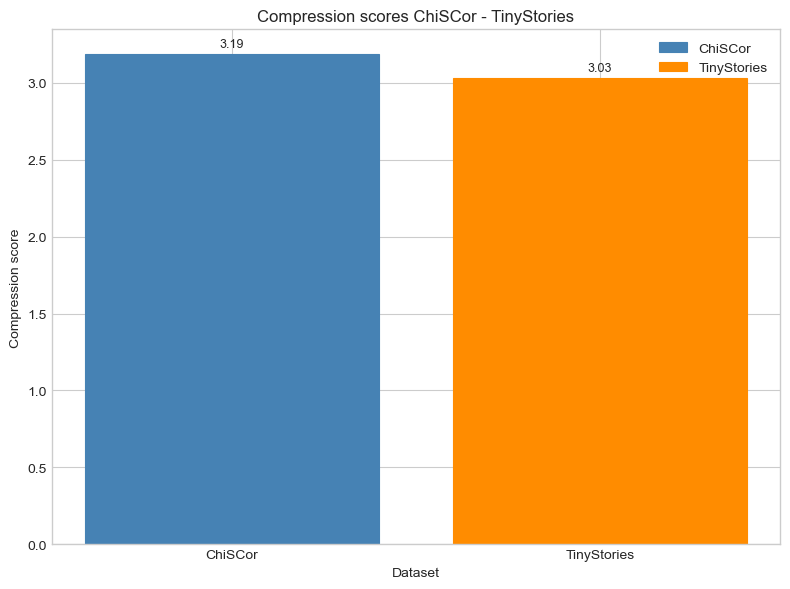

In [265]:
plot_two_bars(cr_chiscor, cr_tinystories, label1='ChiSCor', label2='TinyStories', title='Compression scores ChiSCor - TinyStories', xlabel='Dataset', ylabel='Compression score')

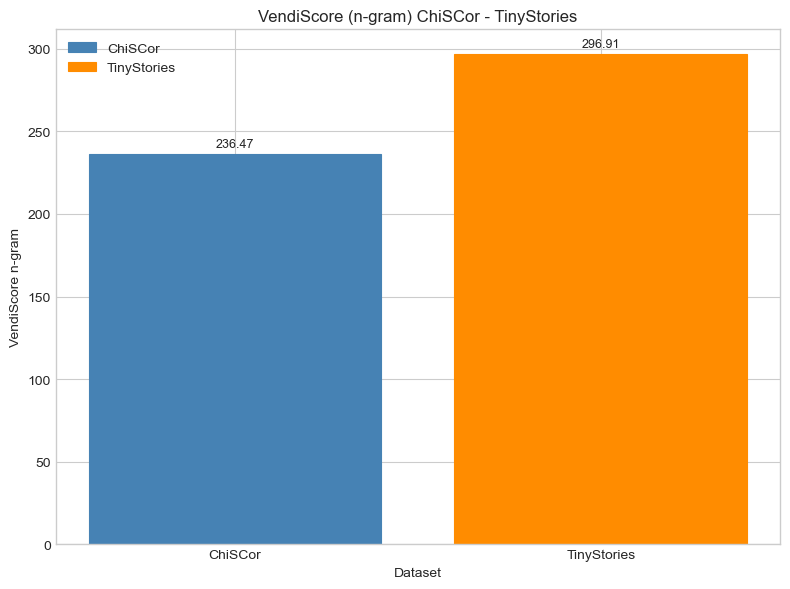

In [264]:
plot_two_bars(ngram_vs_chiscor, ngram_vs_tiny, label1='ChiSCor', label2='TinyStories', title='VendiScore (n-gram) ChiSCor - TinyStories', xlabel='Dataset', ylabel='VendiScore n-gram')

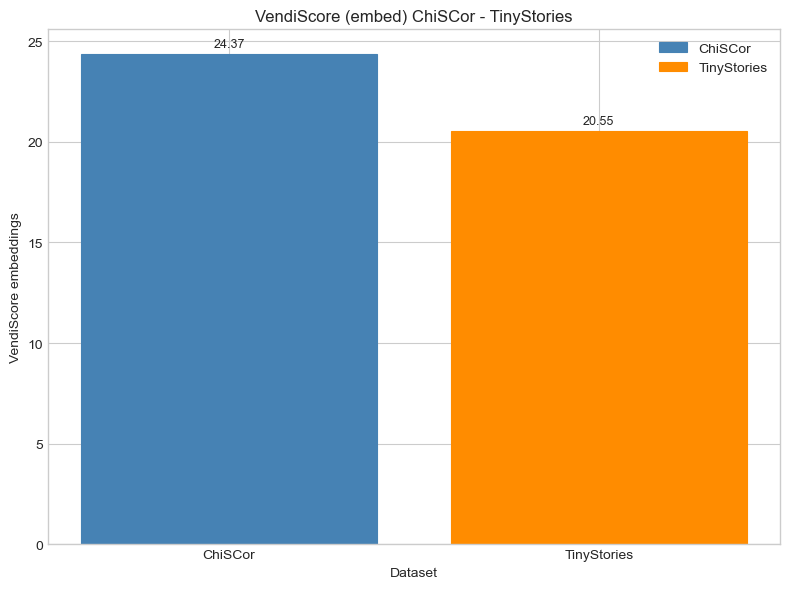

In [263]:
plot_two_bars(embed_vs_chiscor, embed_vs_tiny, label1='ChiSCor', label2='TinyStories', title='VendiScore (embed) ChiSCor - TinyStories', xlabel='Dataset', ylabel='VendiScore embeddings')

In [262]:
def plot_two_bars(value1,
                  value2,
                  *,
                  figure_size=(8, 6),
                  title='Dependency-constraint perplexities',
                  xlabel='Model',
                  ylabel='Value',
                  label1='TinyStories',
                  label2='TinyStories',
                  annotate=True):
    """
    Plot two bars side-by-side with the same look-and-feel as the overlapping histogram:
    - steelblue & darkorange colors
    - alpha=0.6 transparency
    - legend, title, axis labels
    """
    plt.figure(figsize=figure_size)

    # Draw the two bars (separate calls so legend picks them up cleanly)
    b1 = plt.bar(0, value1, color='steelblue', edgecolor='steelblue', linewidth=0.8, label=label1)
    b2 = plt.bar(1, value2, color='darkorange', edgecolor='darkorange', linewidth=0.8, label=label2)

    # Axes labels, ticks, title, legend
    plt.xticks([0, 1], [label1, label2])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()

    # Optional value annotations on top of bars
    if annotate:
        for bar_container in (b1, b2):
            rect = bar_container[0]
            h = rect.get_height()
            plt.annotate(f'{h:.2f}',
                         xy=(rect.get_x() + rect.get_width() / 2, h),
                         xytext=(0, 3),
                         textcoords='offset points',
                         ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


## Plotting and analysis

In [242]:
def plot_histogram(data, binsize=30, figure_size=(8,6), title='Dependency-constraint perplexities', xlabel='Perplexity', ylabel='Frequency'):
    plt.figure(figsize=figure_size)
    plt.hist(data, bins=binsize, edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis='y', alpha=0.75)

In [22]:
def plot_overlapping_hist(data1,
                          data2, 
                          *,
                          binsize=30, 
                          figure_size=(8,6), 
                          title='Dependency-constraint perplexities', 
                          xlabel='Perplexity', 
                          ylabel='Frequency',
                          label1='TinyStories',
                          label2='TinyStories'):
    data1_norm = (data1 - np.mean(data1)) / np.std(data1)
    data2_norm = (data2 - np.mean(data2)) / np.std(data2)

    plt.figure(figsize=figure_size)
    plt.hist(data1_norm, bins=binsize, color='steelblue', alpha=0.6, label=label1)
    plt.hist(data2_norm, bins=binsize, color='darkorange', alpha=0.6, label=label2)

    # Add labels and legend
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()

In [174]:
def plot_violin_plot(data1, data2, *, xlabels=None, ylabel=None, title=None, outliers=False, showmeans=True, showmedians=True, showextrema=True):
    _, ax = plt.subplots()

    data = [data1, data2]

    cleaned = []
    labels = []
    for i, g in enumerate(data, start=1):
        g = np.asarray(g)
        g = g[np.isfinite(g)] 
        if g.size >= 2 and np.nanstd(g) > 0:
            cleaned.append(g)
            labels.append(i)              # keep index for positions
        # else: skip this group; it can’t form a violin

    axes = ax.violinplot(cleaned, showmeans=showmeans, showmedians=showmedians, showextrema=showextrema)

    axes['cmeans'].set_linestyle("-")
    axes['cmedians'].set_linestyle("--")

    # Custom legend handles
    legend_elements = [
        Line2D([0], [0], color="steelblue", lw=1, linestyle="-", label="Mean"),
        Line2D([0], [0], color="steelblue", lw=1, linestyle="--", label="Median")
    ]

    # Overlay a boxplot with fliers (outliers)
    if outliers:
        ax.boxplot(cleaned, positions=[1, 2], widths=0.1,
                showfliers=True,
                showcaps=False,
                boxprops={'color':'none'},
                whiskerprops={'linewidth':0},
                medianprops={'linewidth':0},
                flierprops=dict(marker='D', markerfacecolor='steelblue', markersize=4,
                        linestyle='none', markeredgecolor='steelblue'))
        legend_elements.append(Line2D([0], [0], marker='D', color='w', label="Outliers",
           markerfacecolor='steelblue', markeredgecolor='steelblue', markersize=4))

    ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(xlabels)
    ax.set_ylabel(ylabel)
    plt.title(title)

In [68]:
df_chiscor.columns

Index(['id', 'story_lemmatized', 'story_raw', 'story_raw_no_newlines',
       'story_no', 'chardepth', 'labels', 'labels_int', 'agegroup',
       'treedepth_WNU', 'compl_avg', 'wbr_avg', 'msTTR', 'maTTR', 'MTLD',
       'MTLD_mov', 'MTLD_bi', 'HDD', 'story_PP', 'dep_dist', 'agegroup_str',
       'syntactic_depth', 'average_components', 'wbr_average',
       'lexical_diversity', 'dependency_distance', 'local_contextuality',
       'grammaticality', 'creative_perplexity_unigram',
       'creative_perplexity_bigram', 'creative_perplexity_bigram_constrained',
       'vendi_ngram', 'vendi_embeddings'],
      dtype='object')

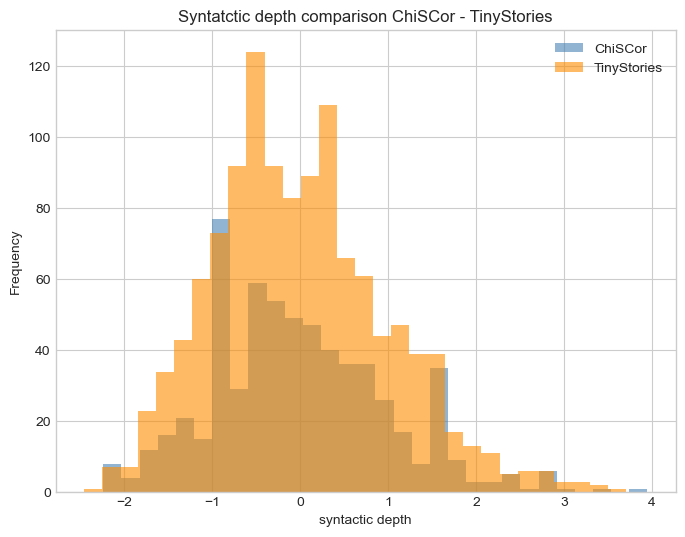

In [26]:
plot_overlapping_hist(df_chiscor['syntactic_depth'], 
                      tinystories_dutch['syntactic_depth'],
                      title='Syntatctic depth comparison ChiSCor - TinyStories',
                      xlabel='syntactic depth',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )


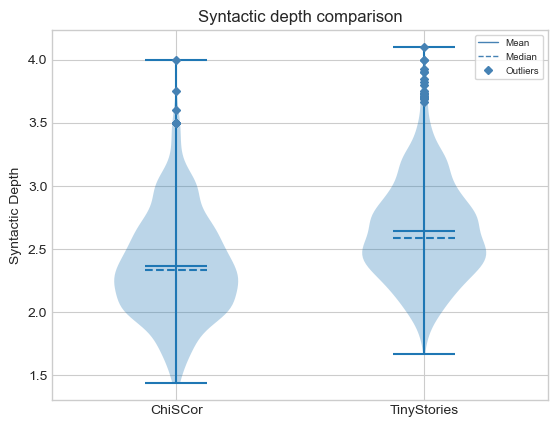

In [82]:
plot_violin_plot(df_chiscor['syntactic_depth'], 
                 tinystories_dutch['syntactic_depth'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Syntactic Depth',
                 title="Syntactic depth comparison", 
                 outliers=True)

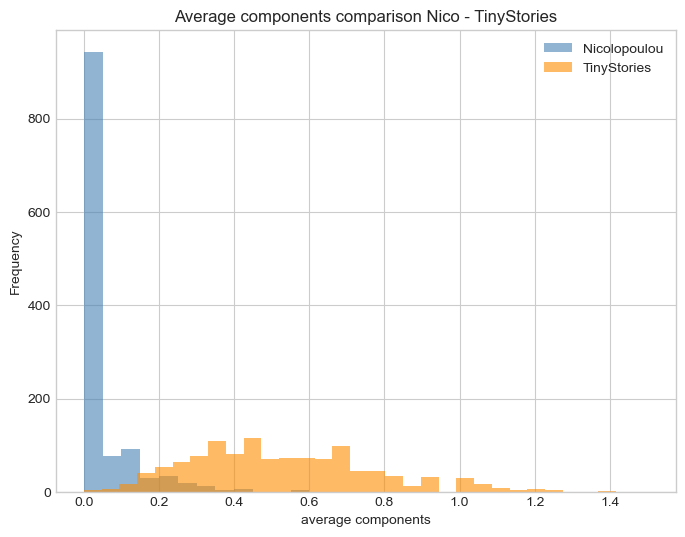

In [ ]:
plot_overlapping_hist(df_chiscor['average_components'], 
                      tinystories_dutch['average_components'],
                      title='Average components comparison ChiSCor - TinyStories',
                      xlabel='average components',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )


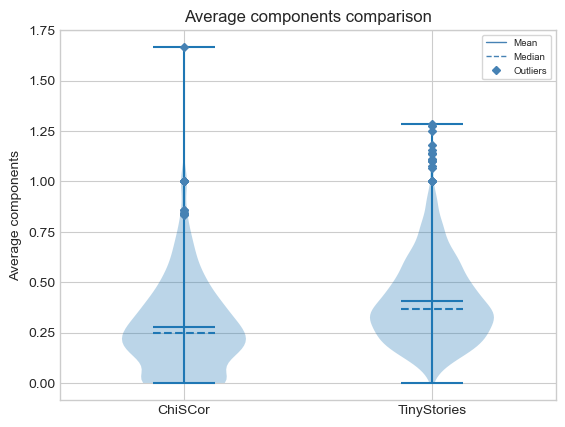

In [83]:
plot_violin_plot(df_chiscor['average_components'], 
                 tinystories_dutch['average_components'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Average components',
                 title="Average components comparison", 
                 outliers=True)

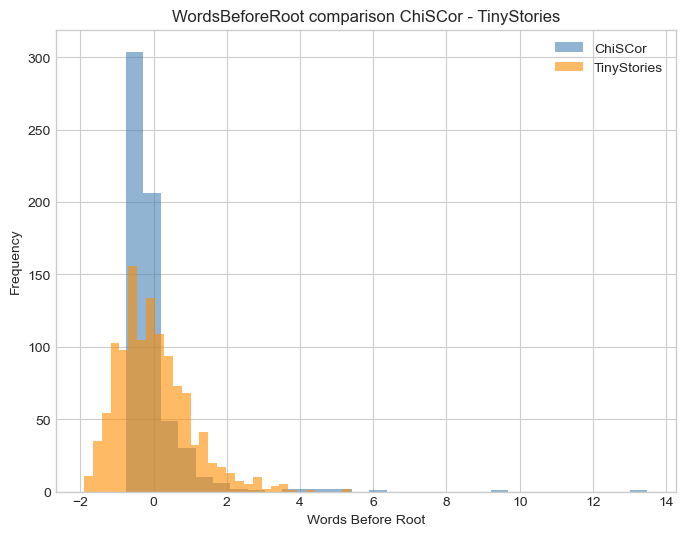

In [76]:
plot_overlapping_hist(df_chiscor['wbr_average'], 
                      tinystories_dutch['wbr_average'],
                      title='WordsBeforeRoot comparison ChiSCor - TinyStories',
                      xlabel='Words Before Root',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )

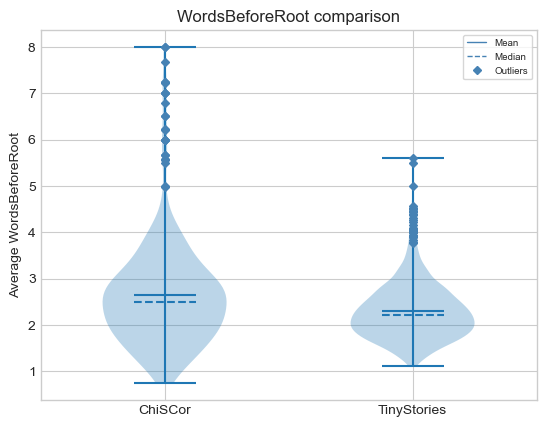

In [84]:
plot_violin_plot(df_chiscor['wbr_average'], 
                 tinystories_dutch['wbr_average'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Average WordsBeforeRoot',
                 title="WordsBeforeRoot comparison", 
                 outliers=True)

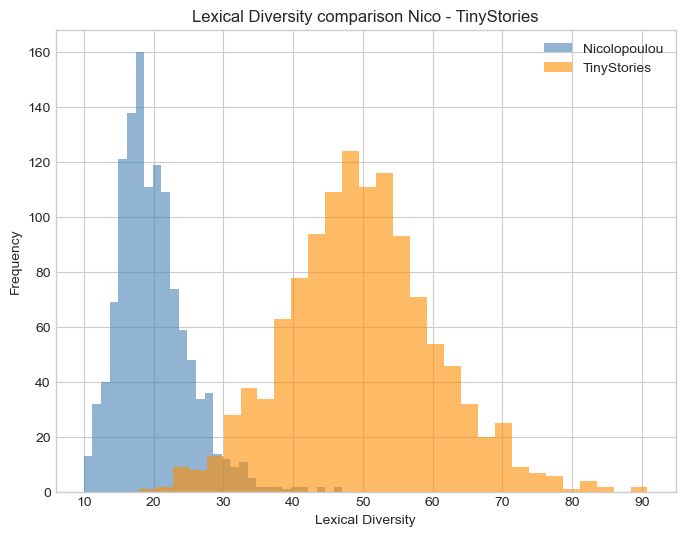

In [ ]:
plot_overlapping_hist(df_chiscor['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(), 
                      tinystories_dutch['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(),
                      title='Lexical Diversity comparison Nico - TinyStories',
                      xlabel='Lexical Diversity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

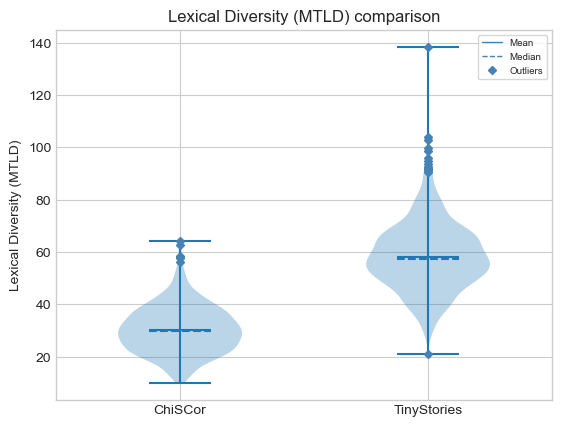

In [85]:
plot_violin_plot(df_chiscor['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(), 
                 tinystories_dutch['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(), 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Lexical Diversity (MTLD)',
                 title="Lexical Diversity (MTLD) comparison", 
                 outliers=True)

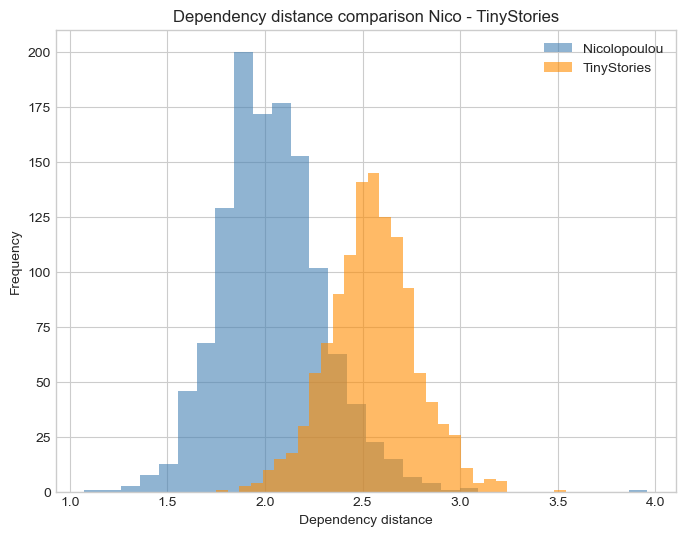

In [ ]:
plot_overlapping_hist(df_chiscor['dependency_distance'], 
                      tinystories_dutch['dependency_distance'],
                      title='Dependency distance comparison Nico - TinyStories',
                      xlabel='Dependency distance',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

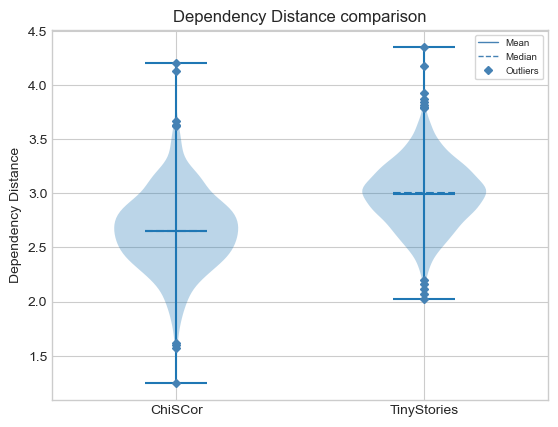

In [86]:
plot_violin_plot(df_chiscor['dependency_distance'], 
                 tinystories_dutch['dependency_distance'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Dependency Distance',
                 title="Dependency Distance comparison", 
                 outliers=True)

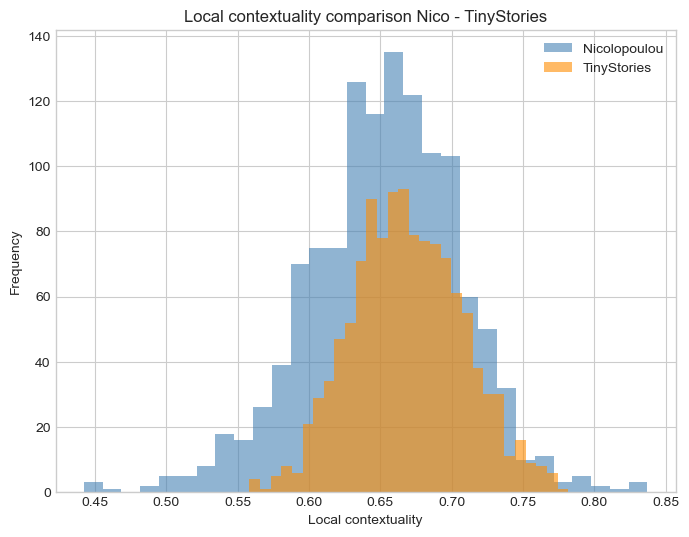

In [ ]:
plot_overlapping_hist(df_chiscor['local_contextuality'][df_chiscor['local_contextuality'] > 0.01].tolist(), # took out the 0.0 (no sentences)
                      tinystories_dutch['local_contextuality'],
                      title='Local contextuality comparison ChiSCor - TinyStories',
                      xlabel='Local contextuality',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )

Info: 0.0 values are skipped. These are instances with only 1 sentence.
      Skipped 11 stories ([25, 173, 193, 340, 353, 392, 452, 478, 506, 516, 567]). 


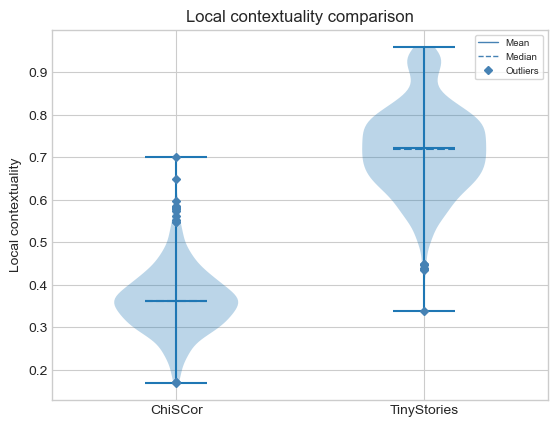

In [87]:
zero_values = df_chiscor['local_contextuality'].isin([0.0])

print(f"""Info: 0.0 values are skipped. These are instances with only 1 sentence.
      Skipped {zero_values.sum(axis=0)} stories ({df_chiscor.index[zero_values].tolist()}). """)
plot_violin_plot(df_chiscor['local_contextuality'][df_chiscor['local_contextuality'] != 0.0], 
                 tinystories_dutch['local_contextuality'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Local contextuality',
                 title="Local contextuality comparison", 
                 outliers=True)

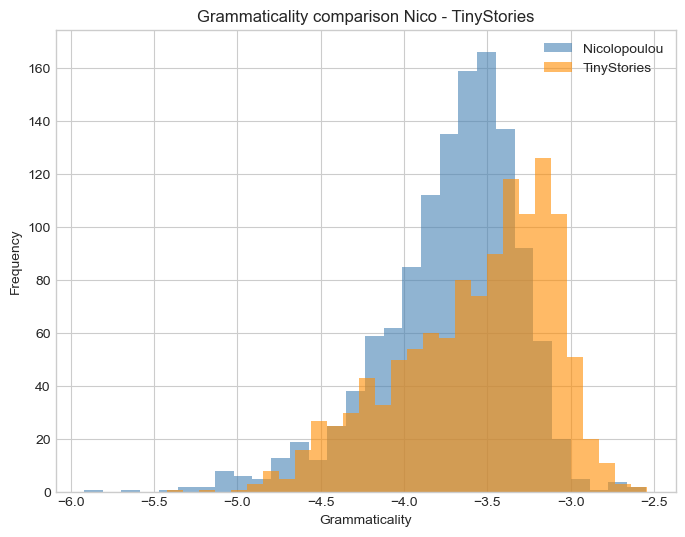

In [ ]:
plot_overlapping_hist(df_chiscor['grammaticality'], 
                      tinystories_dutch['grammaticality'],
                      title='Grammaticality comparison Nico - TinyStories',
                      xlabel='Grammaticality',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

In [ ]:
df_chiscor[df_chiscor['grammaticality'] < -2.4].sort_values(by=['grammaticality'])


,id,story_lemmatized,story_raw,story_raw_no_newlines,story_no,chardepth,labels,labels_int,agegroup,treedepth_WNU,...,dependency_distance,local_contextuality,grammaticality,creative_perplexity_unigram,creative_perplexity_bigram,creative_perplexity_bigram_constrained,vendi_ngram,vendi_embeddings,perplexity_BL,perplexity_WD
506,100901,toen ik jarig was heb ik een krijgen,toen ik jarig was heb ik een Ferrari gekregen.\n,toen ik jarig was heb ik een Ferrari gekregen.,1,1,actor,1,1,2.000000,...,2.222222,0.000000,-2.617744,292.710264,217.780365,66.510485,0.000000,0.000000,12.072299,74.604219
15,10901,mijn papa en mijn mama heten en en ik gaan al...,mijn papa en mijn mama heet en .\nen ik ga al...,mijn papa en mijn mama heet en . en ik ga alti...,1,2,actor,1,1,2.666667,...,2.047619,0.303783,-2.547951,430.468143,660.191263,202.207851,3.604130,3.289067,319.158408,146.220889
481,91701,er zijn eens een tas en die hebben been en ar...,er was eens een tas en die had benen en armen ...,er was eens een tas en die had benen en armen ...,1,8,person,3,6,2.656250,...,2.905371,0.315915,-2.534413,677.614385,282.649100,112.353762,27.744584,14.800115,167.936210,353.852209
236,41202,nou een kussen die leven en een stoel die lev...,nou een kussen die leefde en een stoel die lee...,nou een kussen die leefde en een stoel die lee...,2,4,agent,2,1,2.250000,...,3.153846,0.503539,-2.516487,557.021639,328.365277,382.338669,5.241909,4.185152,531.026598,561.241349
418,73302,er komen eens een en die zien e en toen gaan ...,er kwam eens een Power Ranger.\nen die zag een...,er kwam eens een Power Ranger. en die zag een ...,2,3,agent,2,3,1.750000,...,2.000000,0.344137,-2.495760,1856.542865,427.004765,1650.970326,3.619355,2.864758,2014.637728,176.659862
158,30303,eigenlijk naar de bioscoop en toen gaan ik ki...,eigenlijk naar de bioscoop en toen ging ik Bu...,eigenlijk naar de bioscoop en toen ging ik Buu...,3,4,agent,2,1,1.750000,...,2.456790,0.363662,-2.490552,921.128450,378.593950,73.354907,10.380640,7.332906,95.360464,173.124164
254,42501,ik heb een boek schrijven over en in en en da...,ik heb een boek geschreven over Blue Charlie D...,ik heb een boek geschreven over Blue Charlie D...,1,4,agent,2,6,2.300000,...,2.862069,0.348570,-2.481720,1856.610626,1046.389200,1966.637304,8.652381,6.675314,1401.569361,2741.438479
6,10403,toen er zijn zijn er en daarna ze moeten slap...,toen Kayo er was. \nKayo was er en daarna ze m...,toen Kayo er was. Kayo was er en daarna ze moe...,3,4,agent,2,3,2.333333,...,2.680000,0.454576,-2.458699,599.000957,681.265223,307.724154,2.968910,2.472197,18.739978,2110.453373
392,70701,wij hebben morgen ridder en prinses aan verkl...,wij hadden morgen ridders en prinsessen aan ve...,wij hadden morgen ridders en prinsessen aan ve...,1,1,actor,1,1,4.000000,...,1.875000,0.000000,-2.442717,2390.950057,627.691790,10.481073,0.000000,0.000000,18.575862,25.036136
393,70801,ik hebben twee broer en die heten en en de jo...,ik heb twee broertjes en die heten en .\nen d...,ik heb twee broertjes en die heten en . en de ...,1,2,actor,1,4,2.142857,...,2.482143,0.241374,-2.442020,844.547795,678.714406,36.676653,6.790068,5.027047,161.555226,34.574812


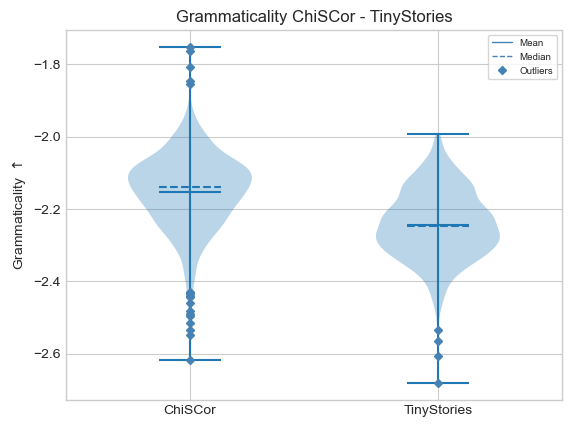

In [88]:
plot_violin_plot(df_chiscor['grammaticality'], 
                 tinystories_dutch['grammaticality'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel=r'Grammaticality $\uparrow$',
                 title="Grammaticality ChiSCor - TinyStories", 
                 outliers=True)

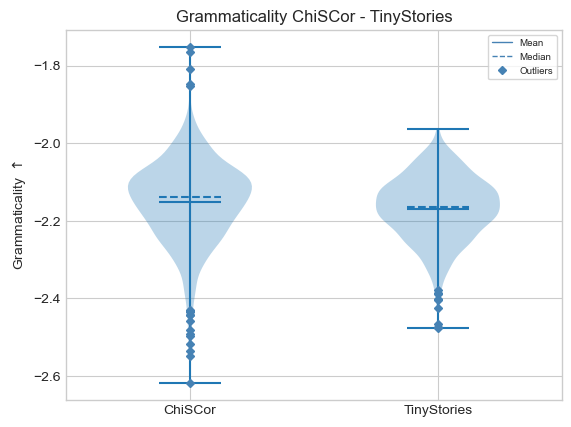

In [112]:
plot_violin_plot(df_chiscor['grammaticality'], 
                 first_prompting['grammaticality'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel=r'Grammaticality $\uparrow$',
                 title="Grammaticality ChiSCor - TinyStories", 
                 outliers=True)

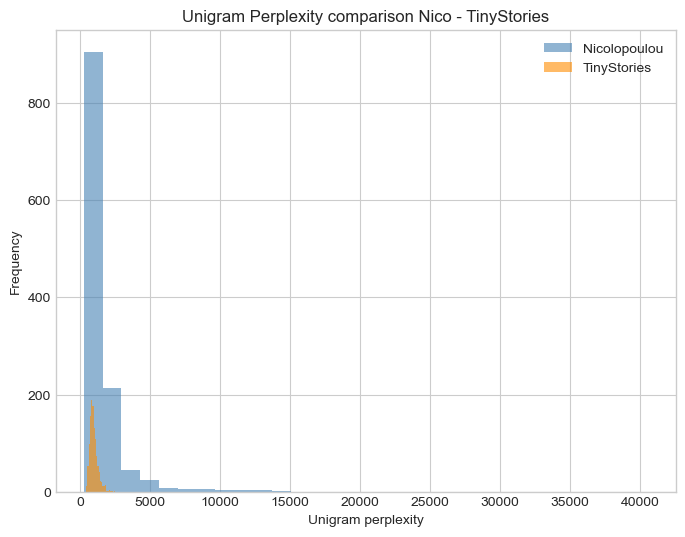

In [ ]:
plot_overlapping_hist(df_chiscor['creative_perplexity_unigram'], 
                      tinystories_dutch['creative_perplexity_unigram'],
                      title='Unigram Perplexity comparison Nico - TinyStories',
                      xlabel='Unigram perplexity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

In [ ]:
df_chiscor['text'].iloc[1041]

'once upon a time Thomas Choo Choo Train and Henry Choo Choo Train and Asher Choo Choo Train pretend crashed. the end.'

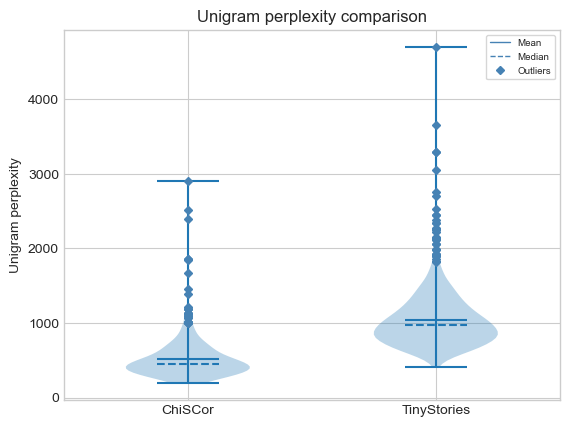

In [89]:
plot_violin_plot(df_chiscor['creative_perplexity_unigram'], 
                 tinystories_dutch['creative_perplexity_unigram'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Unigram perplexity',
                 title="Unigram perplexity comparison", 
                 outliers=True)

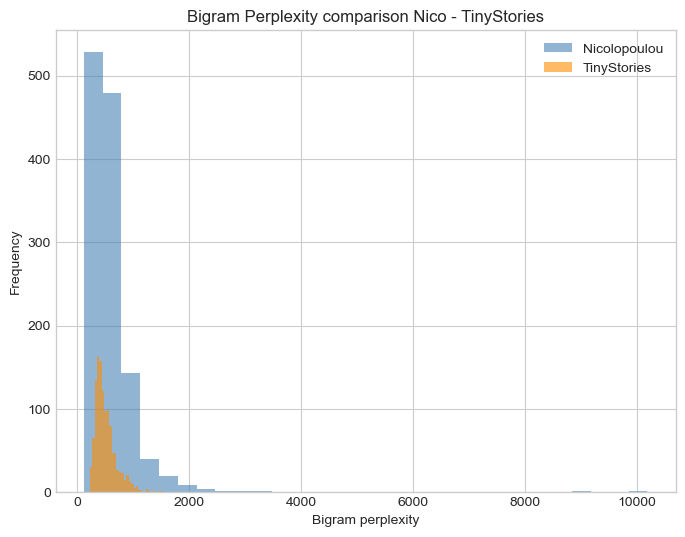

In [ ]:
plot_overlapping_hist(df_chiscor['creative_perplexity_bigram'], 
                      tinystories_dutch['creative_perplexity_bigram'],
                      title='Bigram Perplexity comparison Nico - TinyStories',
                      xlabel='Bigram perplexity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

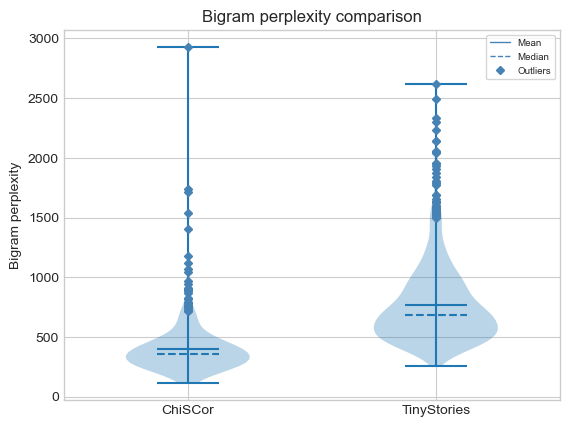

In [90]:
plot_violin_plot(df_chiscor['creative_perplexity_bigram'], 
                 tinystories_dutch['creative_perplexity_bigram'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Bigram perplexity',
                 title="Bigram perplexity comparison", 
                 outliers=True)

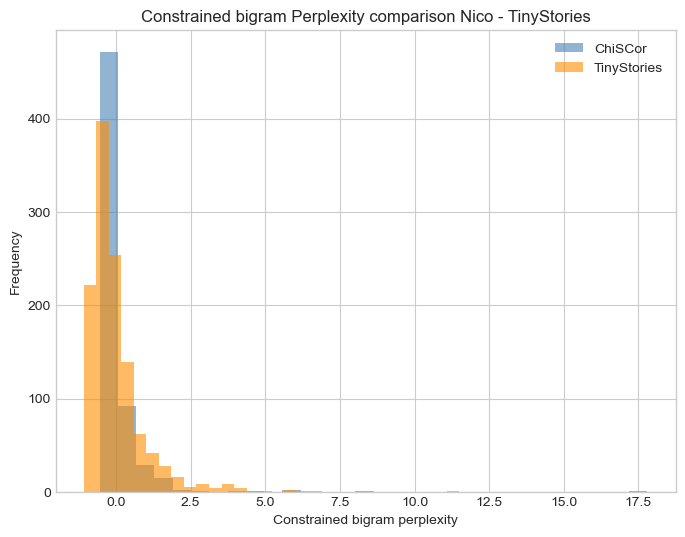

In [84]:
plot_overlapping_hist(df_chiscor['creative_perplexity_bigram_constrained'], 
                      tinystories_dutch['creative_perplexity_bigram_constrained'],
                      title='Constrained bigram Perplexity comparison Nico - TinyStories',
                      xlabel='Constrained bigram perplexity',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )

In [ ]:
outliers = df_chiscor[df_chiscor['creative_perplexity_bigram_constrained'] > 1500]

for idx, story in outliers.iterrows:
    text = story['story_raw']
    gram = story['grammaticality']
    print(text)
    print(gram)


In [ ]:
def plot_violin_plot_with_gram(
    data1, data2, *,
    xlabels=None, ylabel=None, title=None,
    outliers=False, showmeans=True, showmedians=True, showextrema=True,
    grammar1=None, grammar2=None, cmap='viridis', vmin=None, vmax=None
):
    fig, ax = plt.subplots()

    data_list = [np.asarray(data1, dtype=float), np.asarray(data2, dtype=float)]
    gram_list = []
    if grammar1 is not None or grammar2 is not None:
        gram_list = [
            None if grammar1 is None else np.asarray(grammar1, dtype=float),
            None if grammar2 is None else np.asarray(grammar2, dtype=float)
        ]
    else:
        gram_list = [None, None]

    cleaned = []
    gram_cleaned = []
    kept_idx = []

    # Clean NaNs/inf and keep groups that can form a violin
    for i, (vals, grams) in enumerate(zip(data_list, gram_list), start=1):
        mask = np.isfinite(vals)
        vals = vals[mask]
        if grams is not None:
            grams = grams[mask]
        if vals.size >= 2 and np.nanstd(vals) > 0:
            cleaned.append(vals)
            gram_cleaned.append(grams)
            kept_idx.append(i)

    if len(cleaned) == 0:
        raise ValueError("No valid data groups to plot.")

    positions = list(range(1, len(cleaned) + 1))

    vp = ax.violinplot(cleaned, positions=positions,
                       showmeans=showmeans, showmedians=showmedians, showextrema=showextrema)

    # Style mean/median lines if present
    if showmeans and 'cmeans' in vp:
        vp['cmeans'].set_linestyle("-")
    if showmedians and 'cmedians' in vp:
        vp['cmedians'].set_linestyle("--")

    # Custom legend handles for mean/median
    legend_elements = []
    if showmeans:
        legend_elements.append(Line2D([0], [0], color="steelblue", lw=1, linestyle="-", label="Mean"))
    if showmedians:
        legend_elements.append(Line2D([0], [0], color="steelblue", lw=1, linestyle="--", label="Median"))

    # Boxplot overlay (no fliers; we’ll draw them ourselves)
    if outliers:
        ax.boxplot(
            cleaned, positions=positions, widths=0.1,
            showfliers=False, showcaps=False,
            boxprops={'color': 'none'},
            whiskerprops={'linewidth': 0},
            medianprops={'linewidth': 0}
        )

        # Prepare colormap if grammaticality is provided
        have_grammar = any(g is not None for g in gram_cleaned)
        norm = None
        cmap_obj = None
        colorbar_mappable = None

        if have_grammar:
            all_scores = np.concatenate([g for g in gram_cleaned if g is not None])
            finite_scores = all_scores[np.isfinite(all_scores)]
            if finite_scores.size > 0:
                if vmin is None:
                    vmin = np.nanmin(finite_scores)
                if vmax is None:
                    vmax = np.nanmax(finite_scores)
                norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
                cmap_obj = cm.get_cmap(cmap)

        # Compute Tukey outliers and scatter them
        for pos, vals, grams in zip(positions, cleaned, gram_cleaned):
            q1 = np.percentile(vals, 25)
            q3 = np.percentile(vals, 75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            out_mask = (vals < lower) | (vals > upper)
            y_out = vals[out_mask]
            if y_out.size == 0:
                continue
            x_out = np.full_like(y_out, pos, dtype=float)

            if have_grammar and grams is not None and norm is not None and cmap_obj is not None:
                g_out = grams[out_mask]
                sc = ax.scatter(
                    x_out, y_out, marker='D', s=30,
                    c=g_out, cmap=cmap_obj, norm=norm,
                    edgecolors='black', linewidths=0.2, zorder=3
                )
                colorbar_mappable = sc  # keep last for colorbar
            else:
                ax.scatter(
                    x_out, y_out, marker='D', s=30,
                    c='steelblue', edgecolors='black', linewidths=0.2, zorder=3
                )

        # Legend + colorbar
        if have_grammar and norm is not None:
            legend_elements.append(
                Line2D([0], [0], marker='D', color='w',
                       label='Outliers (color = grammaticality)',
                       markerfacecolor='gray', markeredgecolor='black', markersize=4)
            )
            cbar = fig.colorbar(colorbar_mappable, ax=ax)
            cbar.set_label('Grammaticality')
        else:
            legend_elements.append(
                Line2D([0], [0], marker='D', color='w',
                       label="Outliers", markerfacecolor='steelblue',
                       markeredgecolor='steelblue', markersize=4)
            )

    if legend_elements:
        ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=7)

    # X labels (respect cleaned/kept groups)
    if xlabels is None:
        xticklabels = [f'G{i}' for i in kept_idx]
    else:
        xticklabels = [xlabels[i-1] for i in kept_idx]
    ax.set_xticks(positions)
    ax.set_xticklabels(xticklabels)

    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    plt.tight_layout()
    return fig, ax


In [268]:
df_chiscor['story_raw'].iloc[591]

' nou een wolf at een vogeltje op en die spuugde het uit op een klein kindje.\nen toen was het kindje dood door de wolf.\nen toen was de wolf dood door de ridder.\nen hij is afgelopen.'

In [184]:
tinystories_dutch['creative_perplexity_bigram'].idxmax()

215

In [185]:
tinystories_dutch['story_nl'].iloc[215]

'Lily en Ben speelden in de keuken. Ze zagen een grote pot olives op het aanrecht liggen. Lily vond olives lekker, maar Ben niet.\n\n"Kan ik een olie hebben?" vroeg Lily.\n\n"Nee, ze zijn vies," zei Ben.\n\nLily schoof haar hand in de pot en opende hem. Ze nam er een groene olijf uit en stopte hem in haar mond. Ze glimlachte.\n\n"Mmm, ze zijn lekker," zei ze.\n\nBen trok een grimas. Hij wilde geen olijf proberen. Hij zag een stomme mes op het snijplank liggen. Hij pakte het op en imiteerde een keukenhulp.\n\n"Kijk, ik ben een chef!" zei hij.\n\nHij sneed een olijf doormidden en drukte hem. Het sap spetterde uit en raakte zijn oog.\n\n"Oh, oh, oh!", riep hij.\n\nLily liet zakken en rende naar hem toe. Ze zag dat zijn oog rood en vochtig was.\n\n"Hoef je het goed?", vroeg ze.\n\nBen veegde zijn oog en snoof.\n\n"Dat doet pijn," zei hij.\n\nLily omhelsde hem en zei, "Sorry. Laat me even een handdoek halen."\n\nZe rende naar het aanrecht en pakte een handdoek. Ze kwam terug en wreef voorzi

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_72445/2106176293.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


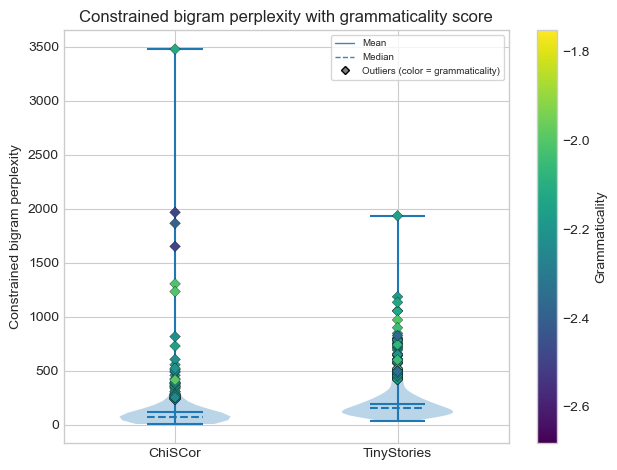

In [176]:
fig, ax = plot_violin_plot_with_gram(
    df_chiscor['creative_perplexity_bigram_constrained'], tinystories_dutch['creative_perplexity_bigram_constrained'],
    xlabels=["ChiSCor", "TinyStories"],
    ylabel="Constrained bigram perplexity",
    title="Constrained bigram perplexity with grammaticality score",
    outliers=True,
    grammar1=df_chiscor['grammaticality'],
    grammar2=tinystories_dutch['grammaticality'],
    cmap='viridis'                    # any Matplotlib cmap
)

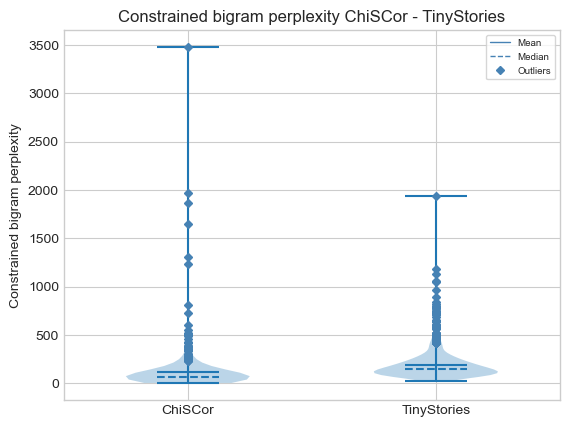

In [175]:
plot_violin_plot(df_chiscor['creative_perplexity_bigram_constrained'], 
                 tinystories_dutch['creative_perplexity_bigram_constrained'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Constrained bigram perplexity',
                 title='Constrained bigram perplexity ChiSCor - TinyStories', 
                 outliers=True)

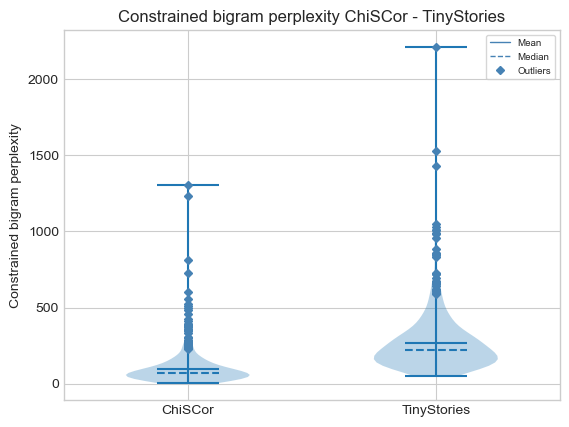

In [105]:
plot_violin_plot(df_chiscor['creative_perplexity_bigram_constrained'][df_chiscor['creative_perplexity_bigram_constrained'] < 1500].tolist(), 
                 first_prompting['creative_perplexity_bigram_constrained'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Constrained bigram perplexity',
                 title='Constrained bigram perplexity ChiSCor - TinyStories', 
                 outliers=True)

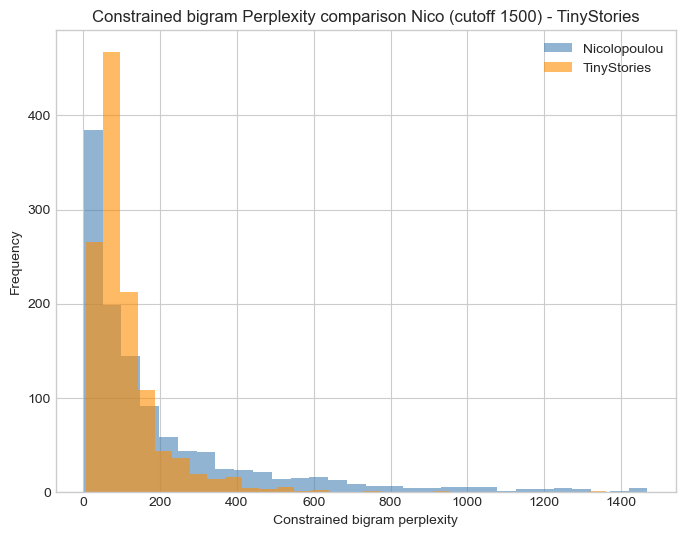

In [ ]:
plot_overlapping_hist(df_chiscor['creative_perplexity_bigram_constrained'][df_chiscor['creative_perplexity_bigram_constrained'] < 1500].tolist(), 
                      tinystories_dutch['creative_perplexity_bigram_constrained'],
                      title='Constrained bigram Perplexity comparison Nico (cutoff 1500) - TinyStories',
                      xlabel='Constrained bigram perplexity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

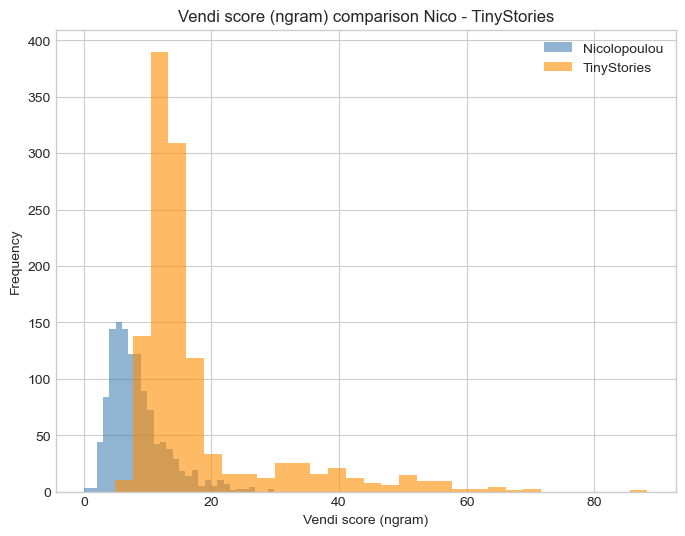

In [ ]:
plot_overlapping_hist(df_chiscor['vendi_ngram'], 
                      tinystories_dutch['vendi_ngram'],
                      title='Vendi score (ngram) comparison Nico - TinyStories',
                      xlabel='Vendi score (ngram)',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

In [ ]:
df_chiscor['vendi_ngram'][df_chiscor['vendi_ngram'] < 200]

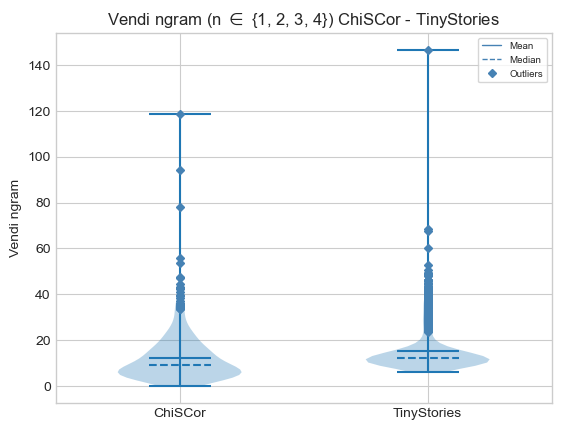

In [109]:
plot_violin_plot(df_chiscor['vendi_ngram'][df_chiscor['vendi_ngram'] < 200], 
                 tinystories_dutch['vendi_ngram'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Vendi ngram',
                 title=r'Vendi ngram (n $\in$ {1, 2, 3, 4}) ChiSCor - TinyStories', 
                 outliers=True)

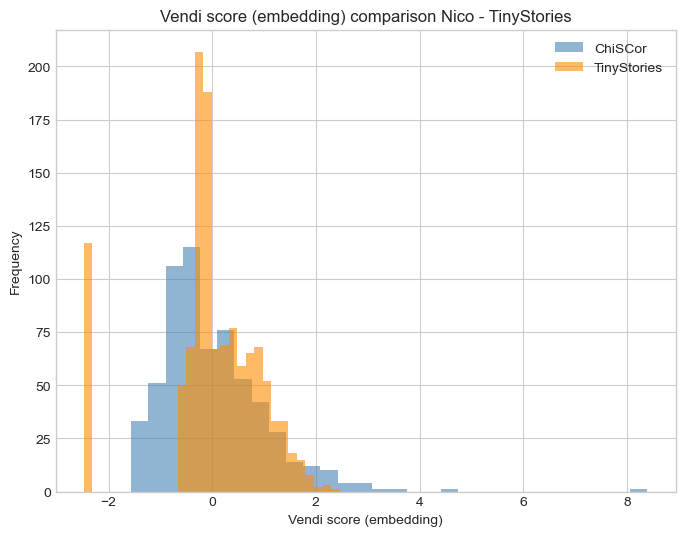

In [93]:
plot_overlapping_hist(df_chiscor['vendi_embeddings'], 
                      tinystories_dutch['vendi_embeddings'],
                      title='Vendi score (embedding) comparison Nico - TinyStories',
                      xlabel='Vendi score (embedding)',
                      label1='ChiSCor',
                      label2='TinyStories'
                      )

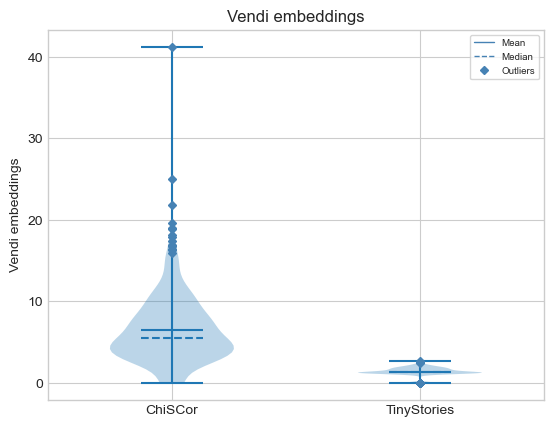

In [108]:
plot_violin_plot(df_chiscor['vendi_embeddings'], 
                tinystories_dutch['vendi_embeddings'], 
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Vendi embeddings',
                 title='Vendi embeddings', 
                 outliers=True)

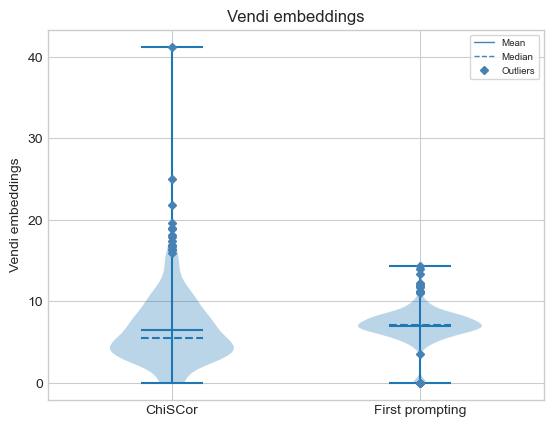

In [111]:
plot_violin_plot(df_chiscor['vendi_embeddings'], 
                first_prompting['vendi_embeddings'], 
                 xlabels=['ChiSCor', 'First prompting'], 
                 ylabel='Vendi embeddings',
                 title='Vendi embeddings', 
                 outliers=True)

In [324]:
def vendi_test(text: str):
    text = text.replace('\n', '')
    sents = list(map(str, list(nlp(text).sents)))

    if len(sents) < 2:
        return 0.0

    try:
        return float(
                text_utils.embedding_vendi_score(sents, model_path='jegormeister/bert-base-dutch-cased')
            )
    except Exception:
        return 0.0

### ChiSCor like vendi V2

In [322]:
chiscor_like_v2 = pd.read_csv('/Users/sabijn/Documents/PhD/code/storylm_p1_data/results/prompt_ChiSCor_like_V2.csv')

In [325]:
chiscor_like_v2['vendi_embedding'] = chiscor_like_v2.apply(lambda row: vendi_test(row['completion']), axis = 1)

In [327]:
embed_vs_chiscor_syn_V2 = text_utils.embedding_vendi_score(list(map(str, chiscor_like_v2['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')

In [329]:
embed_vs_chiscor_syn_V2

10.879343

In [328]:
cr_syn_chiscor_V2 = compression_ratio(chiscor_like_v2['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio chiscor: {cr_syn_chiscor_V2:.4f}")

Compression Ratio chiscor: 2.9790


### ChiSCor like V1 vendi

In [297]:
chiscor_like['vendi_embedding'] = chiscor_like.apply(lambda row: vendi_test(row['completion']), axis = 1)

In [317]:
text_utils.embedding_vendi_score(test_story, model_path='jegormeister/bert-base-dutch-cased')

13.023405

In [321]:
chiscor_like['completion'].iloc[0]

'Er was eens een klein dorpje, verscholen tussen de hoge bomen van een dicht bos. In dit dorpje woonde eenagate houthakker genaamd Hans. Hij was een van de sterkste mannen in het dorp en het liefst hakte hij de hele dag bomen om om geld te verdienen.\n\nOp een dag kreeg Hans een speciale opdracht. De burgemeester van het dorp vroeg hem om een enorm houten standbeeld te maken van een draak. Het standbeeld moest in het midden van het dorp gezet worden en Hans zou er veel geld voor krijgen.\n\nHans ging meteen aan het werk. Hij hakte een reusachtige boom om en begon het hout te snijden in de vorm van een prachtige draak. Het duurde een paar dagen, maar toen was het eindelijk klaar.\n\nDe burgemeester was sangat tevreden en vroeg Hans om het standbeeld te gaan verven. Hans koos voor een helderrode kleur en begon te schilderen. Toen hij klaar was, stond er een geweldig standbeeld in het midden van het dorp.\n\nMaar op de avond van de onthulling gebeurde er iets vreemds. Het standbeeld begon

In [ ]:
embed_vs_chiscor_syn = text_utils.embedding_vendi_score(list(map(str, chiscor_like['completion'].to_list())), model_path='jegormeister/bert-base-dutch-cased')
embed_vs_chiscor_syn

In [ ]:
cr_syn_chiscor = compression_ratio(synthetic_chiscor['completion'].to_list(), algorithm='gzip')
print(f"Compression Ratio chiscor: {cr_syn_chiscor:.4f}")

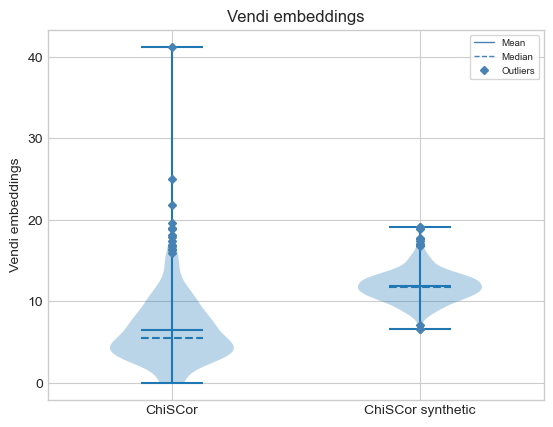

In [332]:
plot_violin_plot(df_chiscor['vendi_embeddings'], 
                chiscor_like_v2['vendi_embedding'][chiscor_like_v2['vendi_embedding'] > 0.0], 
                 xlabels=['ChiSCor', 'ChiSCor synthetic'], 
                 ylabel='Vendi embeddings',
                 title='Vendi embeddings', 
                 outliers=True)

In [333]:
def plot_three_violins(data1, data2, data3, *, xlabels=None, ylabel=None, title=None, outliers=False, showmeans=True, showmedians=True, showextrema=True):
    _, ax = plt.subplots()

    data = [data1, data2, data3]

    cleaned = []
    labels = []
    for i, g in enumerate(data, start=1):
        g = np.asarray(g)
        g = g[np.isfinite(g)] 
        if g.size >= 2 and np.nanstd(g) > 0:
            cleaned.append(g)
            labels.append(i)              # keep index for positions
        # else: skip this group; it can’t form a violin

    axes = ax.violinplot(cleaned, showmeans=showmeans, showmedians=showmedians, showextrema=showextrema)

    axes['cmeans'].set_linestyle("-")
    axes['cmedians'].set_linestyle("--")

    # Custom legend handles
    legend_elements = [
        Line2D([0], [0], color="steelblue", lw=1, linestyle="-", label="Mean"),
        Line2D([0], [0], color="steelblue", lw=1, linestyle="--", label="Median")
    ]

    # Overlay a boxplot with fliers (outliers)
    if outliers:
        ax.boxplot(cleaned, positions=[1, 2, 3], widths=0.1,
                showfliers=True,
                showcaps=False,
                boxprops={'color':'none'},
                whiskerprops={'linewidth':0},
                medianprops={'linewidth':0},
                flierprops=dict(marker='D', markerfacecolor='steelblue', markersize=4,
                        linestyle='none', markeredgecolor='steelblue'))
        legend_elements.append(Line2D([0], [0], marker='D', color='w', label="Outliers",
           markerfacecolor='steelblue', markeredgecolor='steelblue', markersize=4))

    ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=7)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(xlabels)
    ax.set_ylabel(ylabel)
    plt.title(title)

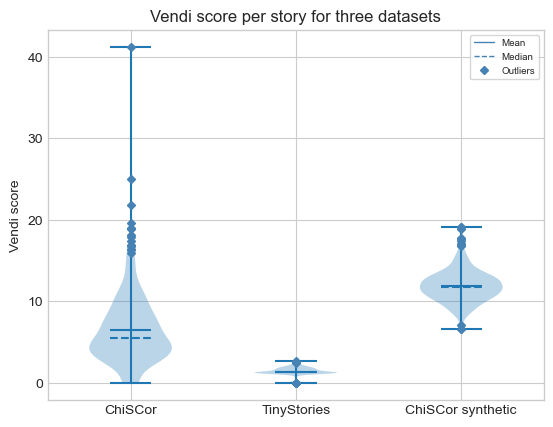

In [336]:
plot_three_violins(df_chiscor['vendi_embeddings'], 
                   tinystories_dutch['vendi_embeddings'],
                chiscor_like_v2['vendi_embedding'][chiscor_like_v2['vendi_embedding'] > 0.0], 
                 xlabels=['ChiSCor', 'TinyStories', 'ChiSCor synthetic'], 
                 ylabel='Vendi score',
                 title='Vendi score per story for three datasets', 
                 outliers=True)

## Different reference corpora

In [ ]:
BL_standard_dep = Path('datasets/BasiLex/BL_dep_lexicon.csv')

eval_f_consumpation_ref = EvaluationFramework(language='nl',
                              pos_unigram=ref_spoken_u_csv, 
                              pos_bigram=ref_spoken_b_csv,
                              pos_trigram=ref_spoken_t_csv,
                              ref_unigram=ref_standard_uni,
                              ref_bigram=ref_standard_bi,
                              ref_ling_constrained=BL_standard_dep,
                              embedding_model='jegormeister/bert-base-dutch-cased')

In [68]:
WD_standard_dep = Path('datasets/WikiDutch/WD_dep_lexicon.csv')

eval_f_WD_ref = EvaluationFramework(language='nl',
                              pos_unigram=ref_spoken_u_csv, 
                              pos_bigram=ref_spoken_b_csv,
                              pos_trigram=ref_spoken_t_csv,
                              ref_unigram=ref_standard_uni,
                              ref_bigram=ref_standard_bi,
                              ref_ling_constrained=WD_standard_dep,
                              embedding_model='jegormeister/bert-base-dutch-cased')

In [69]:
eval_f_consumpation_ref.add_pipe('creative_perplexity_bigram_constrained')
eval_f_WD_ref.add_pipe('creative_perplexity_bigram_constrained')

In [61]:
df_chiscor['perplexity_BL'] = df_chiscor.apply(lambda row: eval_f_consumpation_ref.run_component('creative_perplexity_bigram_constrained', row['story_raw_no_newlines']), axis = 1) 
tinystories_dutch['perplexity_BL'] = tinystories_dutch.apply(lambda row: eval_f_consumpation_ref.run_component('creative_perplexity_bigram_constrained', row['story_nl']), axis = 1) 

In [76]:
df_chiscor['perplexity_WD'] = df_chiscor.apply(lambda row: eval_f_WD_ref.run_component('creative_perplexity_bigram_constrained', row['story_raw_no_newlines']), axis = 1) 
tinystories_dutch['perplexity_WD'] = tinystories_dutch.apply(lambda row: eval_f_WD_ref.run_component('creative_perplexity_bigram_constrained', row['story_nl']), axis = 1) 

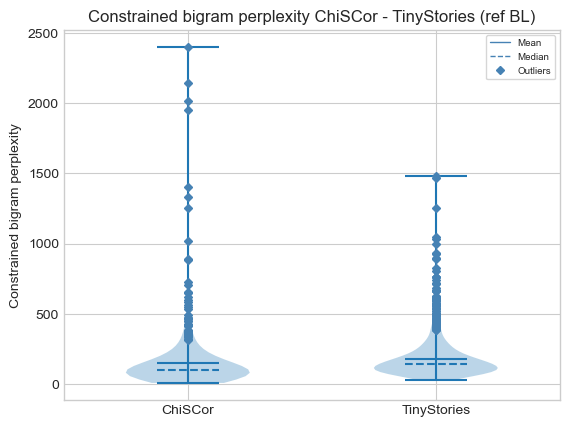

In [96]:
plot_violin_plot(df_chiscor['perplexity_BL'], 
                 tinystories_dutch['perplexity_BL'],
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Constrained bigram perplexity',
                 title='Constrained bigram perplexity ChiSCor - TinyStories (ref BL)', 
                 outliers=True)

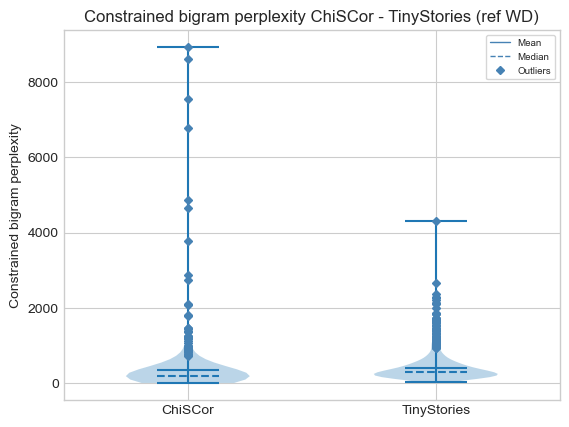

In [198]:
plot_violin_plot(df_chiscor['perplexity_WD'][df_chiscor['perplexity_WD'] < 10_000], 
                 tinystories_dutch['perplexity_WD'],
                 xlabels=['ChiSCor', 'TinyStories'], 
                 ylabel='Constrained bigram perplexity',
                 title='Constrained bigram perplexity ChiSCor - TinyStories (ref WD)', 
                 outliers=True)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_72445/2106176293.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


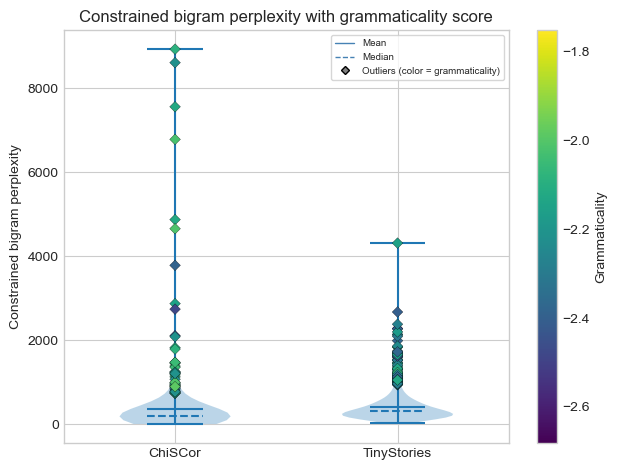

In [199]:
fig, ax = plot_violin_plot_with_gram(
    df_chiscor['perplexity_WD'][df_chiscor['perplexity_WD'] < 10_000], tinystories_dutch['perplexity_WD'],
    xlabels=["ChiSCor", "TinyStories"],
    ylabel="Constrained bigram perplexity",
    title="Constrained bigram perplexity with grammaticality score",
    outliers=True,
    grammar1=df_chiscor['grammaticality'][df_chiscor['perplexity_WD'] < 10_000],
    grammar2=tinystories_dutch['grammaticality'],
    cmap='viridis'                    # any Matplotlib cmap
)

In [211]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_violin_plot4(
    data1, data2, data3, data4, *,
    xlabels=None,
    ylabel=None,
    title=None,
    outliers=False,
    showmeans=True,
    showmedians=True,
    showextrema=True,
    left_color="steelblue",
    right_color="tomato",
    alpha=0.6
):
    _, ax = plt.subplots()

    data = [data1, data2, data3, data4]

    # Clean and keep only plottable groups
    cleaned = []
    for g in data:
        g = np.asarray(g)
        g = g[np.isfinite(g)]
        if g.size >= 2 and np.nanstd(g) > 0:
            cleaned.append(g)

    if len(cleaned) == 0:
        raise ValueError("None of the provided datasets can form a violin (need at least 2 finite, non-constant values).")

    positions = list(range(1, len(cleaned) + 1))

    # Violin plot
    axes = ax.violinplot(
        cleaned,
        positions=positions,
        showmeans=showmeans,
        showmedians=showmedians,
        showextrema=showextrema
    )

    # Colors per group (first two = left, rest = right)
    colors_per_group = []
    for i, body in enumerate(axes["bodies"]):
        col = left_color if i < 2 else right_color
        colors_per_group.append(col)
        body.set_facecolor(col)
        body.set_edgecolor(col)
        body.set_alpha(alpha)

    # Style and COLOR central lines (means/medians) per group
    if showmeans and "cmeans" in axes:
        axes["cmeans"].set_linestyle("-")
        try:
            axes["cmeans"].set_color(colors_per_group)  # LineCollection: one color per segment
        except Exception:
            axes["cmeans"].set_color(left_color)  # fallback
    if showmedians and "cmedians" in axes:
        axes["cmedians"].set_linestyle("--")
        try:
            axes["cmedians"].set_color(colors_per_group)
        except Exception:
            axes["cmedians"].set_color(right_color)  # fallback

    # Color extrema (cbars/cmins/cmaxes) per group with full opacity
    if showextrema:
        for key in ("cbars", "cmins", "cmaxes"):
            if key in axes:
                try:
                    axes[key].set_color(colors_per_group)
                except Exception:
                    axes[key].set_color(left_color)

    # Optional boxplot overlay JUST for fliers, colored per side
    if outliers:
        left_idx  = [i for i in range(min(2, len(cleaned)))]
        right_idx = [i for i in range(2, len(cleaned))]

        if left_idx:
            ax.boxplot(
                [cleaned[i] for i in left_idx],
                positions=[positions[i] for i in left_idx],
                widths=0.1,
                showfliers=True,
                showcaps=False,
                boxprops={'color': 'none'},
                whiskerprops={'linewidth': 0},
                medianprops={'linewidth': 0},
                flierprops=dict(
                    marker='D',
                    markerfacecolor=left_color,
                    markersize=4,
                    linestyle='none',
                    markeredgecolor=left_color
                )
            )
        if right_idx:
            ax.boxplot(
                [cleaned[i] for i in right_idx],
                positions=[positions[i] for i in right_idx],
                widths=0.1,
                showfliers=True,
                showcaps=False,
                boxprops={'color': 'none'},
                whiskerprops={'linewidth': 0},
                medianprops={'linewidth': 0},
                flierprops=dict(
                    marker='D',
                    markerfacecolor=right_color,
                    markersize=4,
                    linestyle='none',
                    markeredgecolor=right_color
                )
            )

    # Legend: show line styles + color groups
    legend_elements = [
        Line2D([0], [0], color=left_color,  lw=1, linestyle="-",  label="Mean (left)"),
        Line2D([0], [0], color=right_color, lw=1, linestyle="-",  label="Mean (right)"),
        Line2D([0], [0], color=left_color,  lw=1, linestyle="--", label="Median (left)"),
        Line2D([0], [0], color=right_color, lw=1, linestyle="--", label="Median (right)"),
        Patch(facecolor=left_color,  edgecolor=left_color,  label="Left violins (1–2)"),
        Patch(facecolor=right_color, edgecolor=right_color, label="Right violins (3–4)")
    ]
    if outliers:
        legend_elements += [
            Line2D([0], [0], marker='D', color='w', label="Outliers (left)",
                   markerfacecolor=left_color, markeredgecolor=left_color, markersize=5),
            Line2D([0], [0], marker='D', color='w', label="Outliers (right)",
                   markerfacecolor=right_color, markeredgecolor=right_color, markersize=5),
        ]
    ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=7)

    # X ticks & labels
    ax.set_xticks(positions)
    if xlabels is None:
        xlabels = [f"Group {i}" for i in positions]
    else:
        xlabels = xlabels[:len(positions)]
    ax.set_xticklabels(xlabels)

    # Labels & title
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    plt.tight_layout()
    return ax


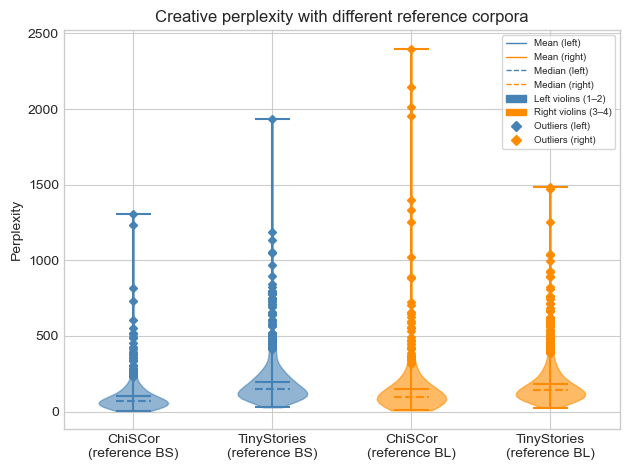

In [212]:
ax = plot_violin_plot4(
    df_chiscor['creative_perplexity_bigram_constrained'][df_chiscor['creative_perplexity_bigram_constrained'] < 1500].tolist(), 
    tinystories_dutch['creative_perplexity_bigram_constrained'], 
    df_chiscor['perplexity_BL'], 
    tinystories_dutch['perplexity_BL'],
    xlabels=["ChiSCor\n(reference BS)","TinyStories\n(reference BS)","ChiSCor\n(reference BL)","TinyStories\n(reference BL)"],
    ylabel="Perplexity",
    title="Creative perplexity with different reference corpora",
    outliers=True,
    left_color="steelblue",
    right_color="darkorange"
)


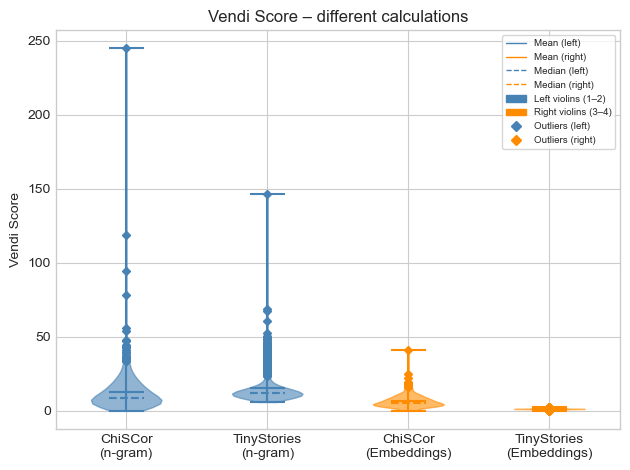

In [213]:
ax = plot_violin_plot4(
    df_chiscor['vendi_ngram'], 
    tinystories_dutch['vendi_ngram'], 
    df_chiscor['vendi_embeddings'], 
    tinystories_dutch['vendi_embeddings'],
    xlabels=["ChiSCor\n(n-gram)","TinyStories\n(n-gram)","ChiSCor\n(Embeddings)","TinyStories\n(Embeddings)"],
    ylabel="Vendi Score",
    title="Vendi Score – different calculations",
    outliers=True,
    left_color="steelblue",
    right_color="darkorange"
)